# Autoencoder - Compression & Reconstruction

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load MNIST sample CSV
3. تجهيز الصور - Normalize and flatten
4. تقسيم البيانات - Train/Test split
5. بناء Autoencoder - Encoder + bottleneck + Decoder
6. compile + fit - Train with MSE reconstruction loss
7. إعادة البناء - Reconstruct test images
8. رسم original vs reconstructed - Visual comparison
9. فضاء latent - 2D projection sample

### أولاً: استيراد المكتبات البرمجية المطلوبة (Import Libraries)
نقوم في هذه الخطوة باستيراد الأدوات والمكتبات اللازمة لمعالجة البيانات، بناء وتدريب النموذج، وتقييم النتائج:

- **`numpy` (المستوردة كـ `np`):** للعمليات الحسابية والتعامل مع المصفوفات الرياضية.
- **`pandas` (المستوردة كـ `pd`):** لقراءة البيانات وإدارة الجداول البرمجية (DataFrames).
- **`matplotlib.pyplot` (المستوردة كـ `plt`):** للرسم البياني وتصور البيانات بصرياً.
- **`train_test_split`:** لتقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار بشكل عشوائي ومنظم.
- **`tensorflow / keras`:** لبناء وتدريب الشبكات العصبية الاصطناعية ونماذج التعلم العميق.


In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

### أولاً: استيراد المكتبات البرمجية المطلوبة (Import Libraries)
نقوم في هذه الخطوة باستيراد الأدوات والمكتبات اللازمة لمعالجة البيانات، بناء وتدريب النموذج، وتقييم النتائج:




In [2]:
# Step 2) قراءة البيانات / Load dataset
import os
import urllib.request

filename = 'mnist_sample.csv'
if not os.path.exists(filename):
    url = 'https://raw.githubusercontent.com/iksasa15/AI-ML/main/code/15-%20Deep%20Learning/7-%20Autoencoder/mnist_sample.csv'
    urllib.request.urlretrieve(url, filename)

dataset = pd.read_csv(filename)
dataset.head()


Shape: (500, 785)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### خطوة: Step 3) تجهيز الصور / Prepare and normalize images
نقوم بتشغيل هذا الجزء من الكود لتنفيذ العمليات البرمجية الموضحة في التعليقات أعلاه لتجهيز البيانات أو تهيئة النموذج.


In [3]:
# Step 3) تجهيز الصور / Prepare and normalize images
pixel_cols = [c for c in dataset.columns if c.startswith('pixel_')]
X = dataset[pixel_cols].values.astype('float32') / 255.0
print('X shape:', X.shape)

X shape: (500, 784)


### ثامناً: تقسيم البيانات إلى مجموعتي تدريب واختبار (Train/Test Split)
نقسم البيانات بنسبة 20% لمجموعة الاختبار وبقية البيانات لمجموعة التدريب:
- **بيانات التدريب (Training Set):** لتعليم النموذج وضبط أوزانه ومعاملاته.
- **بيانات الاختبار (Test Set):** لتقييم النموذج واختبار قدرته على التنبؤ ببيانات جديدة كلياً.


In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (400, 784) | Test: (100, 784)


### عاشراً: بناء وتدريب نموذج الشبكة العصبية الاصطناعية (Neural Network)
1. نقوم بإنشاء كائن من النموذج بالمعاملات المناسبة.
2. نستخدم الدالة `.fit(X_train, y_train)` لتدريب النموذج على بيانات التدريب لكي يتعلم العلاقات والأنماط.


In [5]:
# Step 5) بناء Autoencoder / Encoder -> latent -> Decoder
input_dim = X.shape[1]
latent_dim = 32

inputs = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(inputs)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu', name='latent')(encoded)
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
outputs = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, latent)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

### خطوة: Step 6) compile + fit / Train autoencoder
نقوم بتشغيل هذا الجزء من الكود لتنفيذ العمليات البرمجية الموضحة في التعليقات أعلاه لتجهيز البيانات أو تهيئة النموذج.


In [6]:
# Step 6) compile + fit / Train autoencoder
autoencoder.compile(optimizer='adam', loss='mse')
history = autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2029 - val_loss: 0.1343
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0970 - val_loss: 0.0821
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0774 - val_loss: 0.0791
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0754 - val_loss: 0.0776
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0740 - val_loss: 0.0754
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0727 - val_loss: 0.0741
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0710 - val_loss: 0.0728
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0690 - val_loss: 0.0706
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0667 - val_loss: 0.0686
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0641 - val_loss: 0.0667
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0609 - val_loss: 0.0634
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0569 - val_l

### خطوة: Step 7) إعادة البناء / Reconstruct test images
نقوم بتشغيل هذا الجزء من الكود لتنفيذ العمليات البرمجية الموضحة في التعليقات أعلاه لتجهيز البيانات أو تهيئة النموذج.


In [7]:
# Step 7) إعادة البناء / Reconstruct test images
reconstructed = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean((X_test - reconstructed) ** 2)
print(f'Test reconstruction MSE: {test_mse:.6f}')

Test reconstruction MSE: 0.043364


### الرابع عشر: رسم النتائج بيانيا (Visualization of Results)
نقوم برسم النقاط الحقيقية (الحمراء عادة) والخط أو المنحنى الممثل للنموذج (الأزرق) بصرياً:
- يساعدنا الرسم البياني في التحقق البصري المباشر من مدى دقة التوقعات وملاءمة النموذج للبيانات الحقيقية.


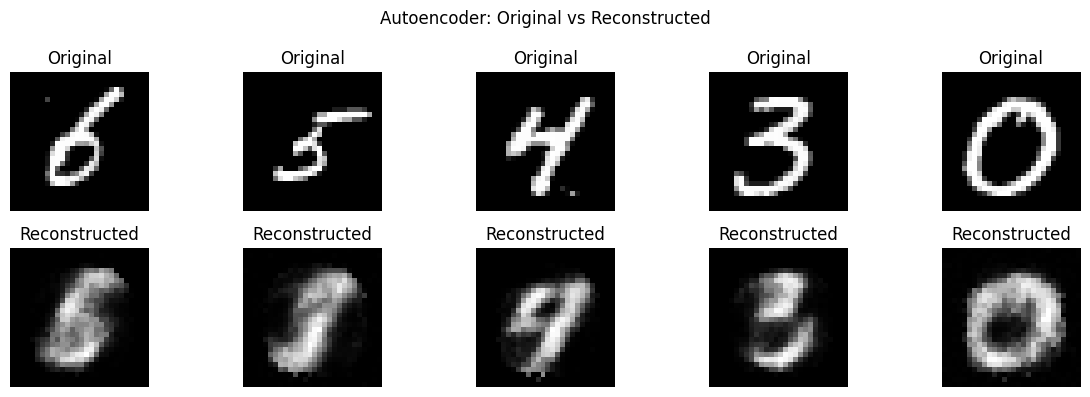

In [8]:
# Step 8) original vs reconstructed / Visual comparison
n = 5
fig, axes = plt.subplots(2, n, figsize=(12, 4))
for i in range(n):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')
plt.suptitle('Autoencoder: Original vs Reconstructed')
plt.tight_layout()
plt.show()

### الرابع عشر: رسم النتائج بيانيا (Visualization of Results)
نقوم برسم النقاط الحقيقية (الحمراء عادة) والخط أو المنحنى الممثل للنموذج (الأزرق) بصرياً:
- يساعدنا الرسم البياني في التحقق البصري المباشر من مدى دقة التوقعات وملاءمة النموذج للبيانات الحقيقية.


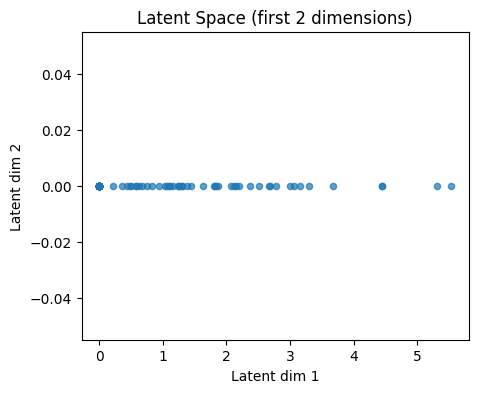

Bottleneck compresses 784 pixels -> 32 dimensions.


In [9]:
# Step 9) فضاء latent / Latent space (first 2 dims for visualization)
latent_codes = encoder.predict(X_test[:100], verbose=0)
plt.figure(figsize=(5, 4))
plt.scatter(latent_codes[:, 0], latent_codes[:, 1], alpha=0.7, s=20)
plt.xlabel('Latent dim 1')
plt.ylabel('Latent dim 2')
plt.title('Latent Space (first 2 dimensions)')
plt.show()
print(f'Bottleneck compresses {input_dim} pixels -> {latent_dim} dimensions.')